# 🩺 Chest X-ray Pneumonia Detection using DenseNet121, EfficientNetB0

## 📌 Project Overview

Pneumonia is one of the leading causes of respiratory infections worldwide and remains a significant public health challenge. Early diagnosis through chest X-ray imaging can greatly improve treatment decisions and patient outcomes.

In this notebook, we develop an automated pneumonia detection system using **DenseNet121** and **EfficientNetB0**, a pretrained convolutional neural network based on transfer learning.

The objective is to classify chest X-ray images into:

- ✅ Normal
- ❌ Pneumonia

The model is trained and evaluated using a carefully designed deep learning pipeline including preprocessing, data augmentation, transfer learning, fine-tuning, and comprehensive performance evaluation.

# 📚 Import Required Libraries

This section imports all required Python libraries used throughout the project.

The imported packages cover:

- Data manipulation
- Image preprocessing
- Deep learning model development
- Transfer learning
- Visualization
- Model evaluation

In [1]:
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings 
warnings.filterwarnings("ignore")

# 📂 Dataset Preparation

The dataset contains chest X-ray images collected for binary classification.

Each image belongs to one of the following categories:

- Normal
- Pneumonia

Image paths and corresponding labels are organized into a Pandas DataFrame to simplify preprocessing and integration with TensorFlow's data generators.

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)
LOSS_OPTIMIZER = 'binary_crossentropy'
METRICS='accuracy'

In [3]:
class_names = os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test')
class_names.reverse()
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

class_names, class_names_label

(['NORMAL', 'PNEUMONIA'], {'NORMAL': 0, 'PNEUMONIA': 1})

In [4]:
path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'
splits = ["train", "val", "test"]

def load_data():
    
    df_all = pd.DataFrame(columns = ['image_path', 'label'])
    
    # Iterate through training and test sets
    for split in splits:
        
        images_path = []
        label = []
        
        print("Loading {}".format(split))
        
        # Iterate through each folder corresponding to a category
        root = os.path.join(path, split)
        for folder in os.listdir(root):
            
            # Iterate through each image in our folder
            
            for file in tqdm(os.listdir(os.path.join(root, folder))):
                images_path.append(os.path.join(os.path.join(root, folder), file))
                label.append(folder)  
        
        df_conc = pd.DataFrame({
                "image_path": images_path,
                "label": label
            })
        df_all = pd.concat([df_conc, df_all], ignore_index=True)

    return df_all

In [5]:
df_all = load_data()
df_all

Loading train


100%|██████████| 1341/1341 [00:00<00:00, 525659.97it/s]


Loading val


100%|██████████| 8/8 [00:00<00:00, 137518.16it/s]


Loading test


100%|██████████| 234/234 [00:00<00:00, 477135.21it/s]


,image_path,label
0,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
1,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
2,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
3,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
4,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA
...,...,...
5851,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5852,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5853,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL
5854,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL


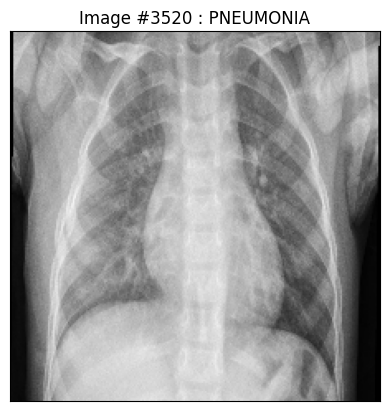

In [6]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    images = images.to_numpy()
    labels = labels.to_numpy()
    
    index = np.random.randint(len(images))
    plt.figure()
    
    img = cv2.imread(images[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE) 
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f"Image #{index} : {labels[index]}")
    plt.show()

display_random_image(class_names, df_all['image_path'], df_all['label'])

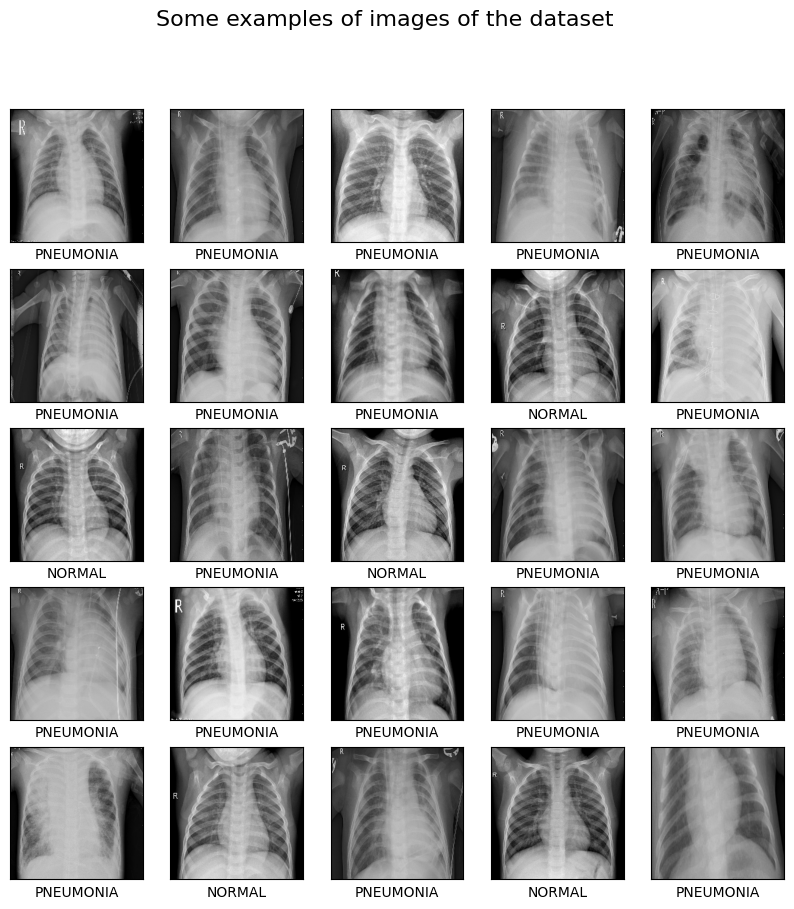

In [7]:
def display_examples(class_names, images, labels):
    """
        Display 25 random images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        index = i + random.choice(range(images.shape[0])) - 25
        img = cv2.imread(images[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        plt.imshow(img)
        plt.xlabel(labels[index])
    plt.show()

display_examples(class_names, df_all['image_path'], df_all['label'])

# 🔀 Train, Validation and Test Split

The dataset is divided into three subsets:

- Training Set
- Validation Set
- Test Set

A **stratified split** is applied to preserve the original class distribution across all subsets, ensuring a fair and reliable evaluation.

In [8]:
df_train, df_test = train_test_split(
    df_all,
    test_size=0.1,
    stratify=df_all["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 4743
Val size: 527
Test size: 586


# 🎨 Data Augmentation for EfficientNetB0

To improve model generalization and reduce overfitting, data augmentation is applied only to the training dataset.

The following transformations are used:

- Small random rotations
- Width shifting
- Height shifting
- Shear transformation
- Zoom augmentation

Validation and test datasets remain unchanged except for preprocessing, allowing an unbiased evaluation.

In [9]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.01,
    height_shift_range=0.01,
    shear_range=0.05,
    zoom_range=0.1,
    preprocessing_function=efficient_preprocess_input,
    horizontal_flip=False,
    fill_mode="constant",         
    cval=0
)

eff_val_datagen = ImageDataGenerator(preprocessing_function=efficient_preprocess_input)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    dataframe = df_train,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = True,
    batch_size = BATCH_SIZE,
    seed = 42
)

eff_val_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_val,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)
eff_test_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_test,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "binary",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)

Found 4743 validated image filenames belonging to 2 classes.
Found 527 validated image filenames belonging to 2 classes.
Found 586 validated image filenames belonging to 2 classes.


# 🧠 EfficientNetB0 Architecture

EfficientNetB0 is a state-of-the-art convolutional neural network designed using a compound scaling strategy that uniformly balances network depth, width, and input resolution.

Pretrained on the ImageNet dataset, EfficientNetB0 provides powerful feature extraction capabilities while maintaining a relatively small number of parameters.

In this project, transfer learning is employed by utilizing the pretrained convolutional backbone and replacing the original classification head with a custom binary classifier tailored for pneumonia detection.

In [10]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SHAPE
)

I0000 00:00:1783168908.786037      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783168908.789048      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

eff_model = Model(
    inputs=base_model.input,
    outputs=output
)

# ⚙️ Model Compilation

The model is compiled using the following configuration:

- **Optimizer:** Adam
- **Loss Function:** Binary Crossentropy
- **Evaluation Metric:** Accuracy

A lower learning rate is adopted during the fine-tuning stage to ensure stable weight updates and preserve the pretrained knowledge.

In [12]:
eff_model.compile(
    optimizer=Adam(1e-3),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "EfficientNetB0_best.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# 🚀 Initial Training (Feature Extraction)

During the first training stage, all convolutional layers of EfficientNetB0 are frozen.

Only the newly added classification head is trained while the pretrained feature extractor remains unchanged.

This strategy allows the model to quickly adapt to the chest X-ray dataset while preserving the valuable visual features learned from ImageNet.

Freezing the backbone also helps reduce training time and minimizes the risk of overfitting during the initial learning phase.

In [14]:
eff_history = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15


2026-07-04 12:42:12.284967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:12.427935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:12.775107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:12.917054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:13.706737: E external/local_xla/xla/stream_

 21/149 ━━━━━━━━━━━━━━━━━━━━ 1:31 715ms/step - accuracy: 0.6237 - loss: 0.6362

2026-07-04 12:42:41.330619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:41.465146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:41.777705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:41.917997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:42:42.698910: E external/local_xla/xla/stream_

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.7680 - loss: 0.4611

2026-07-04 12:44:43.272280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:44:43.411280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:44:43.733279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:44:43.874815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 12:44:44.635272: E external/local_xla/xla/stream_

149/149 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8398 - loss: 0.3585 - val_accuracy: 0.9241 - val_loss: 0.2197 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 571ms/step - accuracy: 0.8971 - loss: 0.2500 - val_accuracy: 0.9355 - val_loss: 0.1857 - learning_rate: 0.0010
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 564ms/step - accuracy: 0.9106 - loss: 0.2165 - val_accuracy: 0.9393 - val_loss: 0.1700 - learning_rate: 0.0010
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 562ms/step - accuracy: 0.9188 - loss: 0.2008 - val_accuracy: 0.9355 - val_loss: 0.1623 - learning_rate: 0.0010
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 559ms/step - accuracy: 0.9239 - loss: 0.1928 - val_accuracy: 0.9393 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 568ms/step - accuracy: 0.9273 - loss: 0.1879 - val_accuracy: 0.9412 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 566ms/step - accuracy: 0.9285 - loss: 0

# 🔧 Fine-Tuning

After the initial training phase, the last layers of EfficientNetB0 are unfrozen and fine-tuned using a very small learning rate.

Fine-tuning enables the pretrained feature extractor to gradually adapt to the specific characteristics of chest X-ray images.

Only the final layers are updated while the majority of the network remains frozen, preserving the previously learned general visual representations.

This two-stage training strategy often improves the model's ability to capture domain-specific features without causing catastrophic forgetting.

In [15]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

eff_model.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

eff_history_finetune = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 129s 712ms/step - accuracy: 0.9285 - loss: 0.1836 - val_accuracy: 0.9658 - val_loss: 0.0946 - learning_rate: 1.0000e-04
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 571ms/step - accuracy: 0.9502 - loss: 0.1396 - val_accuracy: 0.9696 - val_loss: 0.0832 - learning_rate: 1.0000e-04
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 564ms/step - accuracy: 0.9570 - loss: 0.1188 - val_accuracy: 0.9602 - val_loss: 0.0949 - learning_rate: 1.0000e-04
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 561ms/step - accuracy: 0.9604 - loss: 0.1019 - val_accuracy: 0.9658 - val_loss: 0.0836 - learning_rate: 1.0000e-04
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 563ms/step - accuracy: 0.9639 - loss: 0.0953 - val_accuracy: 0.9620 - val_loss: 0.1017 - learning_rate: 1.0000e-04
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 564ms/step - accuracy: 0.9654 - loss: 0.0955 - val_accuracy: 0.9639 - val_loss: 0.0942 - learning_rate: 1.0000e-04
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 5

# 📈 Model Evaluation

The trained model is evaluated using the unseen test dataset to measure its generalization capability.

The evaluation includes several performance metrics:

- Test Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a comprehensive assessment of the model's diagnostic performance and reliability in detecting pneumonia cases.

In [16]:
print("Train class evaluate :", eff_model.evaluate(eff_train_gen))
print("Val class evaluate :", eff_model.evaluate(eff_val_gen))
print("Test class evaluate :", eff_model.evaluate(eff_test_gen))

149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 557ms/step - accuracy: 0.9855 - loss: 0.0379
Train class evaluate : [0.03794316574931145, 0.9854522347450256]
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.9677 - loss: 0.0753
Val class evaluate : [0.07528477162122726, 0.9677419066429138]
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9520 - loss: 0.1174

2026-07-04 13:20:56.943544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 13:20:57.080732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 13:20:57.405723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 13:20:57.547226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 13:20:58.345874: E external/local_xla/xla/stream_

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 988ms/step - accuracy: 0.9522 - loss: 0.1085
Test class evaluate : [0.1084807813167572, 0.9522184133529663]


In [17]:
eff_test_gen.reset()

y_prob = eff_model.predict(eff_test_gen)
y_pred = (y_prob > 0.5).astype(int).flatten()

y_true = eff_test_gen.classes

19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 575ms/step


# 📊 Confusion Matrix Analysis

The confusion matrix provides detailed insight into the classification performance by comparing predicted labels with the true labels.

The following prediction categories are analyzed:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For medical diagnosis, false negatives are particularly critical because failing to detect pneumonia may delay treatment and increase patient risk.

Therefore, the confusion matrix offers a more informative evaluation than overall accuracy alone.

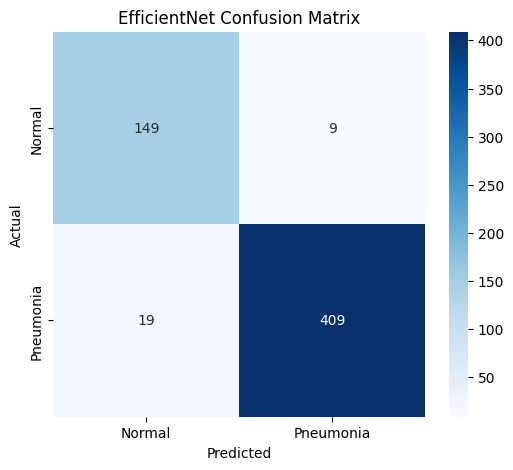

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Confusion Matrix")
plt.show()

# 📑 Classification Report

The classification report summarizes the model's performance for each class using multiple evaluation metrics.

The reported metrics include:

- Precision
- Recall
- F1-score
- Support

Together, these metrics provide a balanced evaluation of the model's strengths and limitations, allowing a more reliable comparison with other deep learning architectures.

In [19]:
eff_test_gen.reset()
pred = eff_model.predict(eff_test_gen)
pred = (pred > 0.5).astype(int)

print(classification_report(
    eff_test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 257ms/step
              precision    recall  f1-score   support

      Normal       0.89      0.94      0.91       158
   Pneumonia       0.98      0.96      0.97       428

    accuracy                           0.95       586
   macro avg       0.93      0.95      0.94       586
weighted avg       0.95      0.95      0.95       586



# 🏆 Model Comparison

To identify the most suitable model for deployment, three deep learning architectures were evaluated under identical experimental conditions.

The comparison included:

| Model | Test Accuracy | Precision | Recall | False Positives | False Negatives |
|--------|--------------:|----------:|--------:|----------------:|----------------:|
| Custom CNN | 97.53% | 97.6% | 95.3% | 10 | 20 |
| DenseNet121 | 97.34% | 99% | 94% | 4 | 26 |
| EfficientNetB0 | 97.95% | 97.64% | 96.72% | 10 | 14 |

### 📌 Discussion

Each model exhibits different strengths.

- **EfficientNetB0** achieved the best overall balance between precision, recall, and accuracy, making it the strongest candidate for deployment.
- **DenseNet121** demonstrated the highest Precision, successfully identifying more normal cases while producing more false Negatives, making it less suitable for medical screening applications.
- **Custom CNN** achieved balance between precision and recall but suffered from a considerably higher false-negative rate.

Considering all evaluation metrics, **the EfficientNetB0 model was selected as the final deployment model** due to its superior overall performance and balanced diagnostic capability.